In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from block_encoding_model import BlockEncodingModel

colors = ["#0087c1", "#f6a800"]

def plot_poly(polys, A, square=False):
    if not isinstance(polys, list):
        polys = [polys]
    xs = np.linspace(-1, 1)
    ys_max = 0
    for i, poly in enumerate(polys):
        if square:
            ys = poly(xs ** 2)
        else:
            ys = poly(xs)
        ys_max = max(ys_max, np.max(np.abs(ys)))
        plt.plot(xs, ys, color=colors[i])
    plt.scatter(A.S, 1/A.S, A.b ** 2 * 100, color="#ad007c")
    plt.ylim([-ys_max - 1, ys_max + 1])
    plt.plot(xs[xs < 0], 1/xs[xs < 0], "k--", linewidth=0.5)
    plt.plot(xs[xs > 0], 1/xs[xs > 0], "k--", linewidth=0.5)
    plt.show()

# The Practical Problems of Quantum Linear System Solvers and a Krylov-based Solution -- Numerical example

We first set up a problem with condition 3 and 1% of noise.

In [2]:
dim = 10
kappa = 3

rng = np.random.default_rng(123)

b = rng.normal(size=dim)
b /= np.linalg.norm(b)

A = BlockEncodingModel(b, kappa=kappa, noise=0.01)

Let us implement the symmetrizised Chebyshev interation polynomial

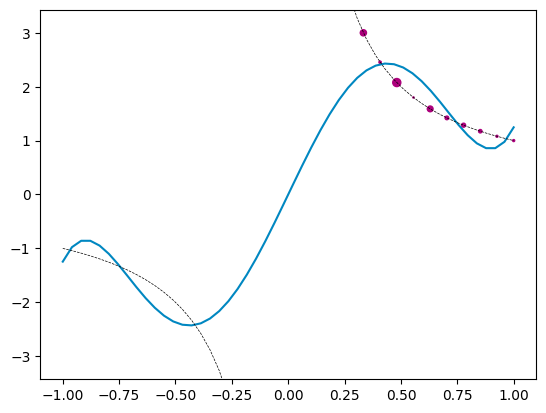

In [3]:
A.reset()

steps = 2
samples = 10000

X = np.polynomial.Chebyshev([0, 1])
poly = np.polynomial.Chebyshev([0] * steps + [0, 1])
poly = poly((X - (1 / kappa**2 + 1) / 2) / (1 - 1 / kappa**2) * 2)
poly = 1 - poly / poly(0)
poly = poly(X ** 2) // X


plot_poly(poly, A)

The error as given in Definition 3

In [4]:
error = A.estimate_error(poly, samples)
complexity = A.complexity()

0.94716838 + 1.01502604·T₁(x) - 0.85937397·T₂(x) - 0.59053138·T₃(x) +
0.67413206·T₄(x)


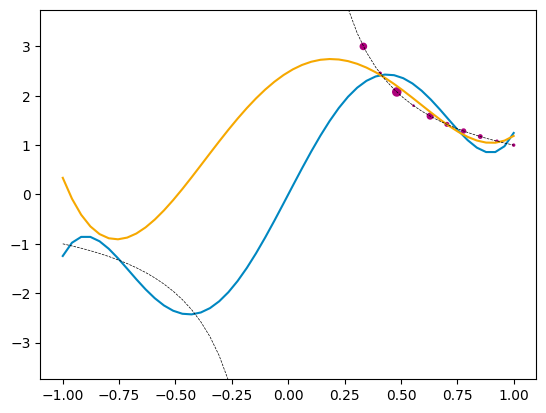

In [10]:
A.reset()

import adaptive_solver

steps = 5
samples = 10000
square = False
sup_norm_constraint = True

poly_adaptive = adaptive_solver.compute_polynomial(A, steps, samples, square, sup_norm_constraint)
plot_poly([poly, poly_adaptive], A)
error_adaptive = A.estimate_error(poly_adaptive, samples)
complexity_adaptive = A.complexity()

In [6]:
print(f"error nonadaptive = {error}")
print(f"error adaptive    = {error_adaptive}")

error nonadaptive = 0.07172726919133213
error adaptive    = 0.061868235329827805


In [7]:
print(f"complexity nonadaptive = {complexity:6}")
print(f"complexity adaptive    = {complexity_adaptive:6}")

complexity nonadaptive =  50000
complexity adaptive    = 400000
